In [1]:
import numpy as np
import pandas as pd
from PIL import Image

In [35]:
# OCR Extraction
import pytesseract

def extract_words_boxes(image_path):
    image = Image.open(image_path).convert("RGB")
    
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

    words = []
    boxes = []

    w, h = image.size  # cleaner

    for i, text in enumerate(data["text"]):
        text = text.strip()
        if not text:
            continue

        conf = int(float(data["conf"][i]))  # safer
        if conf < 40:
            continue

        x, y, bw, bh = (
            data["left"][i],
            data["top"][i],
            data["width"][i],
            data["height"][i]
        )

        box = [
            int(1000 * x / w),
            int(1000 * y / h),
            int(1000 * (x + bw) / w),
            int(1000 * (y + bh) / h),
        ]

        words.append(text)
        boxes.append(box)

    return words, boxes, image

In [36]:
# Group Words into Lines
def group_into_lines(words, boxes, y_threshold=10):
    data = list(zip(words, boxes))
    
    # Sort top to bottom
    data.sort(key=lambda x: x[1][1])
    
    lines = []
    current_line = []
    
    for word, box in data:
        y = box[1]
        
        if not current_line:
            current_line.append((word, box))
            continue
        
        prev_y = current_line[-1][1][1]
        
        if abs(y - prev_y) < y_threshold:
            current_line.append((word, box))
        else:
            lines.append(current_line)
            current_line = [(word, box)]
    
    if current_line:
        lines.append(current_line)
    
    return lines

In [37]:
# Convert Lines to Text
def lines_to_text(lines):
    line_texts = []
    
    for line in lines:
        # Sort left → right
        line = sorted(line, key=lambda x: x[1][0])
        text = " ".join([w for w, _ in line])
        line_texts.append(text)
    
    return line_texts

In [38]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

TRAIN_PATH = BASE_DIR / "receipts" / "train"

TRAIN_IMG_PATH = TRAIN_PATH / "img"

images = list(TRAIN_IMG_PATH.glob("*.jpg"))
sample_image_path = images[24]

(np.float64(-0.5), np.float64(626.5), np.float64(1070.5), np.float64(-0.5))

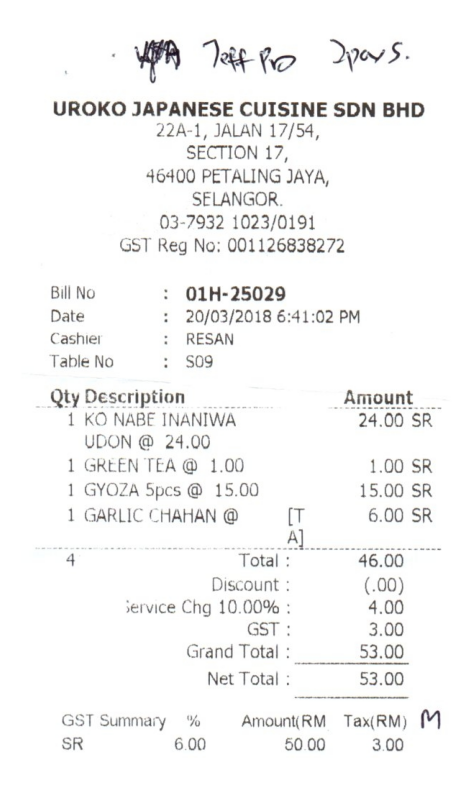

In [39]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(str(sample_image_path))

plt.figure(figsize=(6,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [40]:
lines = group_into_lines(words, boxes)

line_texts = lines_to_text(lines)

line_texts

['WA he 5-',
 'UROKO JAPANESE CUISINE SDN BHD',
 '22A-1, JALAN 17/54,',
 'SECTION 17,',
 '46400 PETALING JAYA,',
 'SELANGOR.',
 '03-7932 1023/0191',
 'GST Reg No; 001126838272',
 'Bill No : O1H-25029',
 'Date : 20/03/2018 6:41:02 PM',
 'Cashier RESAN',
 'Table No : $09',
 'Amount',
 '1 KO NABE INANIWA 24.00 SR',
 'UDON @ 24.00',
 '1 GREEN TEA @ 1.00 1.00 SR',
 '1 GYOZA Specs @ 15.00 15.00 SR',
 '1 GARLIC CHAHAN @ (T 6.00 SR',
 '7 A',
 '“40 Total',
 'Discount : (.00)',
 'service Chg 10.00% : 4.00',
 'GST: 3.00',
 '53.00',
 'Net Total : 53.00',
 'GST Summary % Tax(RM) ™',
 'SR 6.00 50.00 3.00']

In [41]:
from dotenv import load_dotenv
import os
from groq import Groq

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

In [42]:
# Use LLM for Better Extraction
import json

def extract_items_llm(lines):
    context = "\n".join(lines)
    
    prompt = f"""
Extract all items and their prices from this receipt.

Rules:
- Ignore totals, tax, change
- Only return actual purchased items
- Price must be a number

Return ONLY valid JSON:
[
  {{"item": "Milk", "price": 120}},
  {{"item": "Bread", "price": 80}}
]

Receipt:
{context}
"""

    completion = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You extract structured data from receipts."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    response_text = completion.choices[0].message.content

    # Try parsing JSON
    try:
        data = json.loads(response_text)
        return data
    except:
        print("JSON parsing failed, returning raw output")
        return response_text

In [43]:
items = extract_items_llm(line_texts)

items

[{'item': 'KO NABE INANIWA', 'price': 24.0},
 {'item': 'UDON', 'price': 24.0},
 {'item': 'GREEN TEA', 'price': 1.0},
 {'item': 'GYOZA Specs', 'price': 15.0},
 {'item': 'GARLIC CHAHAN', 'price': 6.0}]

In [44]:
import pandas as pd

df_items = pd.DataFrame(items)

df_items

,item,price
0,KO NABE INANIWA,24.0
1,UDON,24.0
2,GREEN TEA,1.0
3,GYOZA Specs,15.0
4,GARLIC CHAHAN,6.0


In [45]:
all_items = []
receipt_id = 1

for img_path in images:
    print(f"\nProcessing: {img_path.name}")
    
    try:
        # OCR
        words, boxes, image = extract_words_boxes(img_path)
        
        # Group lines
        lines = group_into_lines(words, boxes)
        line_texts = lines_to_text(lines)

        # LLM extraction
        items = extract_items_llm(line_texts)
        df_items = pd.DataFrame(items)
        
        # Add receipt_id
        df_items["receipt_id"] = receipt_id
        df_items["file_name"] = img_path.name
        
        all_items.append(df_items)
        receipt_id += 1
        
    except Exception as e:
        print(f"Error processing {img_path.name}: {e}")


Processing: X00016469612.jpg

Processing: X00016469619.jpg

Processing: X00016469622.jpg

Processing: X00016469623.jpg

Processing: X00016469669.jpg

Processing: X00016469671.jpg

Processing: X00016469672.jpg

Processing: X51005200938.jpg

Processing: X51005230605.jpg

Processing: X51005230616.jpg

Processing: X51005230617.jpg

Processing: X51005230621.jpg

Processing: X51005230648.jpg

Processing: X51005255805.jpg

Processing: X51005268200.jpg

Processing: X51005268275.jpg

Processing: X51005268400.jpg

Processing: X51005288570.jpg

Processing: X51005301659.jpg

Processing: X51005301661.jpg

Processing: X51005301666.jpg

Processing: X51005303661.jpg

Processing: X51005306399.jpg

Processing: X51005337872.jpg

Processing: X51005337877.jpg

Processing: X51005361883.jpg

Processing: X51005361895.jpg

Processing: X51005361897.jpg

Processing: X51005361900.jpg

Processing: X51005361908.jpg

Processing: X51005361912.jpg

Processing: X51005361923.jpg

Processing: X51005361946.jpg

Processin

In [46]:
final_df = pd.concat(all_items, ignore_index=True)

final_df.head()

,item,price,receipt_id
0,KF MODELLING CLAY KIDDY FISH,9.00,1
1,ST-PRIVILEGE CARD/GD INDAH,10.00,2
2,GF-TABLE LAMP/STITCH,55.90,2
3,ELEGANT SCH TR BAG,80.91,3
4,ECO AUTO WASH &HAX EW-1000-11,4.62,4


In [47]:
final_df.to_csv("receipt_items.csv", index=False)

In [48]:
RECEIPT_ITEMS_PATH = BASE_DIR / "artifacts" / "receipt_items.csv"

final_df.to_csv(RECEIPT_ITEMS_PATH, index=False)